#  RossParry — YOLOv8 Tomato Leaf Disease Detection
**Real-Time Detection Pipeline | Google Colab**

## Step 1 — Install & Verify

In [1]:
!pip install ultralytics roboflow -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


## Step 2 — Download Dataset from Roboflow

In [2]:
from roboflow import Roboflow

API_KEY = "PCFEECauvgj2ifme3nGc"

rf = Roboflow(api_key=API_KEY)
project = rf.workspace("student-nrpvc").project("tomata-leaf-disease")
version = project.version(3)
dataset = version.download("yolov8")

DATA_YAML = dataset.location + "/data.yaml"
print(" Dataset ready:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Tomata-Leaf-Disease-3 in yolov8:: 100%|██████████| 29610/29610 [00:05<00:00, 5588.36it/s]


 Dataset ready: /content/Tomata-Leaf-Disease-3


## Step 3 — Train YOLOv8n
Using the **nano** variant — best balance of speed and accuracy for real-time deployment.

In [3]:
import time
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

t0 = time.time()
results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    name="rossparry_yolov8n",
    patience=15,
    optimizer="AdamW",
    lr0=0.001,
    augment=True,
    save_period=10,
    verbose=True
)
train_time = time.time() - t0
print(f"\n Training complete in {train_time/60:.1f} min")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Tomata-Leaf-Disease-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rossparry_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 4 — Validate (mAP, Precision, Recall)

In [4]:
best_model = YOLO("runs/detect/rossparry_yolov8n/weights/best.pt")
val = best_model.val(data=DATA_YAML)

print("\n Validation Results:")
print(f"  mAP50      : {val.box.map50:.4f}")
print(f"  mAP50-95   : {val.box.map:.4f}")
print(f"  Precision  : {val.box.mp:.4f}")
print(f"  Recall     : {val.box.mr:.4f}")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1807.1±633.1 MB/s, size: 65.1 KB)
val: Scanning /content/Tomata-Leaf-Disease-3/valid/labels.cache... 1716 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1716/1716 599.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 5.9it/s 18.4s
                   all       1716       5913      0.966      0.949      0.981      0.917
          Early Blight        385        556      0.981      0.959       0.98      0.911
               Healthy        148        380      0.859      0.884       0.93      0.769
           Late Blight        535        792      0.984      0.984      0.993      0.954
            Leaf Miner        387        583      0.981      0.996      0.994      0.954
             Leaf Mold      

## Step 5 — Benchmark Inference Speed (FPS)

In [5]:
import glob, time

test_imgs = glob.glob(dataset.location + "/test/images/*.jpg")[:50]
if not test_imgs:
    test_imgs = glob.glob(dataset.location + "/valid/images/*.jpg")[:50]

# Warmup
for img in test_imgs[:5]:
    best_model.predict(img, verbose=False)

# Benchmark
t0 = time.time()
for img in test_imgs:
    best_model.predict(img, verbose=False)
elapsed = time.time() - t0

fps = len(test_imgs) / elapsed
ms  = elapsed / len(test_imgs) * 1000

print(f"\n Inference Speed:")
print(f"  {fps:.1f} FPS  ({ms:.1f} ms/image)")
print(f"  {' Real-time capable' if fps >= 20 else ' Below 20 FPS — consider reducing imgsz to 416'}")


 Inference Speed:
  90.6 FPS  (11.0 ms/image)
   Real-time capable


## Step 6 — Results Summary

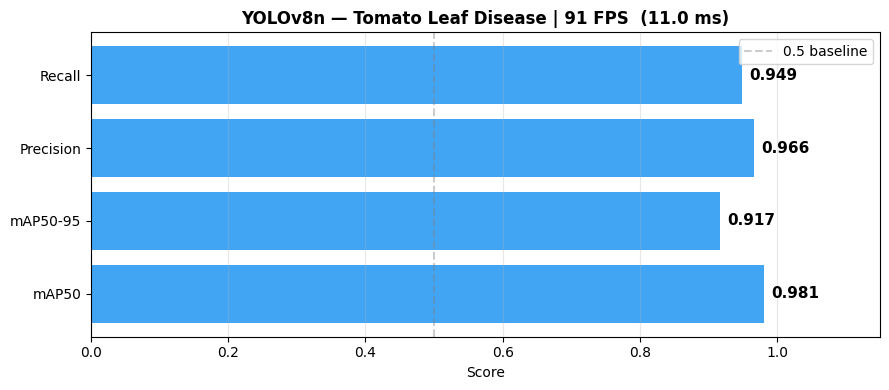

Chart saved as rossparry_results.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

metrics = {
    "mAP50":     val.box.map50,
    "mAP50-95":  val.box.map,
    "Precision": val.box.mp,
    "Recall":    val.box.mr,
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(list(metrics.keys()), list(metrics.values()), color="#2196F3", alpha=0.85)

for bar, val_num in zip(bars, metrics.values()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val_num:.3f}", va="center", fontsize=11, fontweight="bold")

ax.set_xlim(0, 1.15)
ax.set_xlabel("Score")
ax.set_title(f"YOLOv8n — Tomato Leaf Disease | {fps:.0f} FPS  ({ms:.1f} ms)",
             fontweight="bold", fontsize=12)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.4, label="0.5 baseline")
ax.legend()
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("rossparry_results.png", dpi=150)
plt.show()
print("Chart saved as rossparry_results.png")

## Step 7 — Sample Predictions

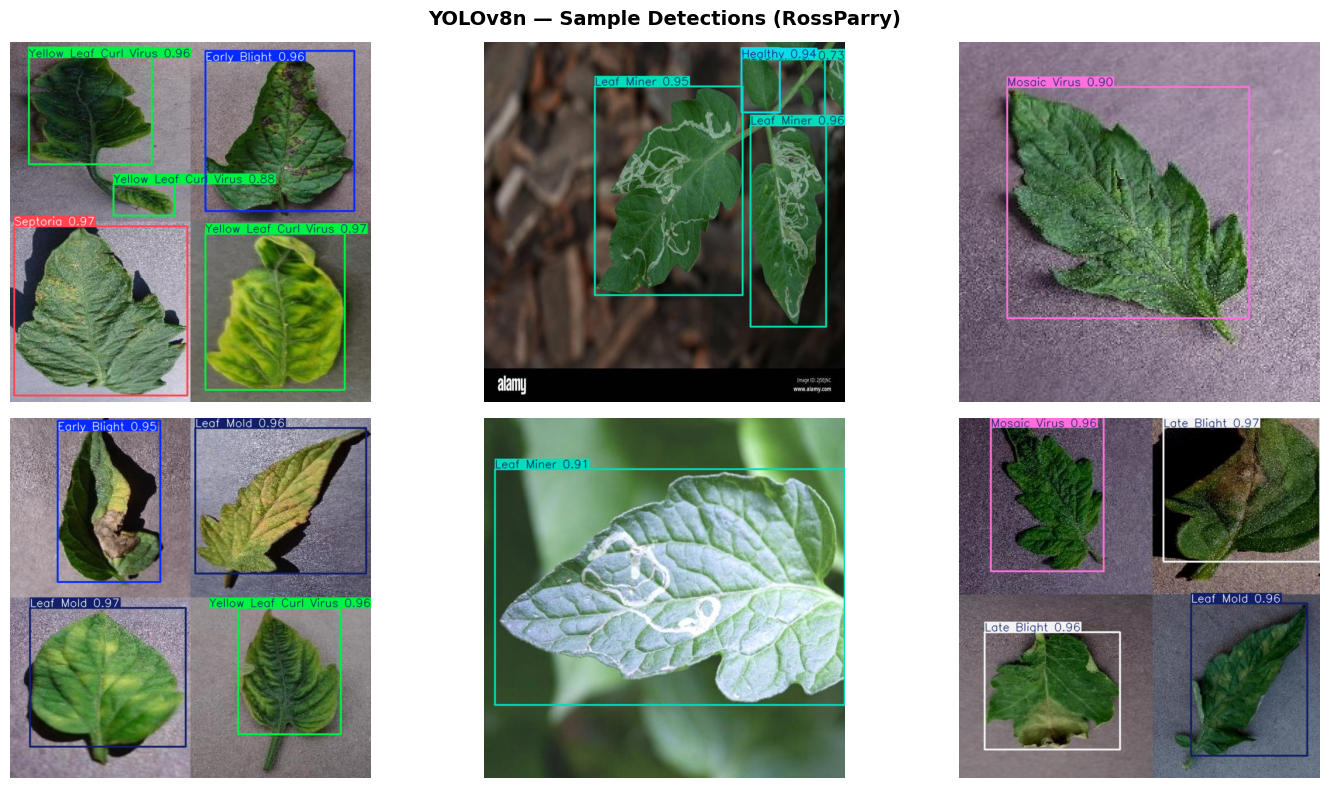

In [7]:
import matplotlib.pyplot as plt

sample = test_imgs[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, img_path in zip(axes.flatten(), sample):
    result = best_model.predict(img_path, verbose=False, conf=0.4)[0]
    plotted = result.plot()[:, :, ::-1]  # BGR → RGB
    ax.imshow(plotted)
    ax.axis("off")

plt.suptitle("YOLOv8n — Sample Detections (RossParry)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_detections.png", dpi=120, bbox_inches="tight")
plt.show()

## Step 8 — Export to ONNX (for RossParry deployment)

In [8]:
export_path = best_model.export(format="onnx", imgsz=640)
print(f"Model exported: {export_path}")
print("Ready to plug into RossParry real-time inference pipeline.")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/rossparry_yolov8n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 13, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 360ms
Prepared 4 packages in 1.79s
Installed 4 packages in 263ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 4.8s, saved as 'runs/detect/rosspa

---
##  Output Files
| File | Description |
|------|-------------|
| `runs/detect/rossparry_yolov8n/weights/best.pt` | Best PyTorch weights |
| `runs/detect/rossparry_yolov8n/weights/last.pt` | Last epoch weights |
| `*.onnx` | Exported model for deployment |
| `rossparry_results.png` | Metrics chart |
| `sample_detections.png` | Visual predictions |


